# Часть 1. Проверка гипотезы в Python и составление аналитической записки

## Описание данных

Данные содержат информацию о пользователях книжного приложения из двух городов — Москвы и Санкт-Петербурга. 

Основные поля:

- puid — количество пользователей

- city — город пользователя (Москва или Санкт-Петербург).

- hours — суммарное количество часов активности пользователя в приложении (чтение и прослушивание книг).

## Содержимое проекта

1. Загрузка и предварительный анализ данных
    - Импорт данных из файла yandex_knigi_data.csv.

    - Проверка на дубликаты

    - Анализ размеров групп и описательных статистик.

    - Визуализация распределения активности по городам.
    

2. Проверка гипотезы
    - Выбор типа t-теста 

    - Определение уровня статистической значимости (α = 0.05).

    - Проведение теста и расчёт p-value.


3. Интерпретация результатов
    - Вывод на основе p-value.

    - Объяснение возможных причин наблюдаемой разницы.




## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('ХХХ')

display(df.head())

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [3]:
# Определение типов данных
display(df.dtypes)

Unnamed: 0      int64
city           object
puid            int64
hours         float64
dtype: object

In [4]:
# Поиск дублей и пропусков
missing_values = df.isnull().sum().sum()
duplicates = df.duplicated().sum()

print(missing_values, duplicates)

0 0


In [5]:
# Поиск дублей и пропусков_puid
missing_values_puid = df['puid'].isnull().sum().sum()
duplicates_puid = df['puid'].duplicated().sum()

print(missing_values_puid, duplicates_puid)

0 244


In [6]:
# Найдены дубликаты в колонке 'puid', теперь удаляем их
print(f"До удаления дубликатов:")
print(f"- Всего строк в датафрейме: {len(df)}")
print(f"- Уникальных значений puid: {df['puid'].nunique()}")
print(f"- Количество дубликатов puid: {df['puid'].duplicated().sum()}")

df_clean = df.drop_duplicates(subset=['puid'], keep='first').copy()

print(f"\nПосле удаления дубликатов:")
print(f"- Всего строк в датафрейме: {len(df_clean)}")
print(f"- Удалено строк: {len(df) - len(df_clean)}")
print(f"- Уникальных значений puid: {df_clean['puid'].nunique()}")

# Находим все дублирующиеся значения
duplicate_values = df[df['puid'].duplicated(keep=False)]['puid'].unique()
print(f"Найдено {len(duplicate_values)} уникальных значений с дубликатами")

# Заменяем исходный датафрейм очищенным
df = df_clean

До удаления дубликатов:
- Всего строк в датафрейме: 8784
- Уникальных значений puid: 8540
- Количество дубликатов puid: 244

После удаления дубликатов:
- Всего строк в датафрейме: 8540
- Удалено строк: 244
- Уникальных значений puid: 8540
Найдено 244 уникальных значений с дубликатами


In [7]:
# Описательная статистика по городам
print("\nОписательная статистика по группам:")
print(df.groupby('city')['hours'].describe())


Описательная статистика по группам:
                  count       mean        std       min       25%       50%  \
city                                                                          
Москва           6234.0  10.881092  36.851683  0.000018  0.059903  0.924498   
Санкт-Петербург  2306.0  11.264433  39.831755  0.000025  0.060173  0.875355   

                      75%         max  
city                                   
Москва           5.939972  857.209373  
Санкт-Петербург  6.138424  978.764775  


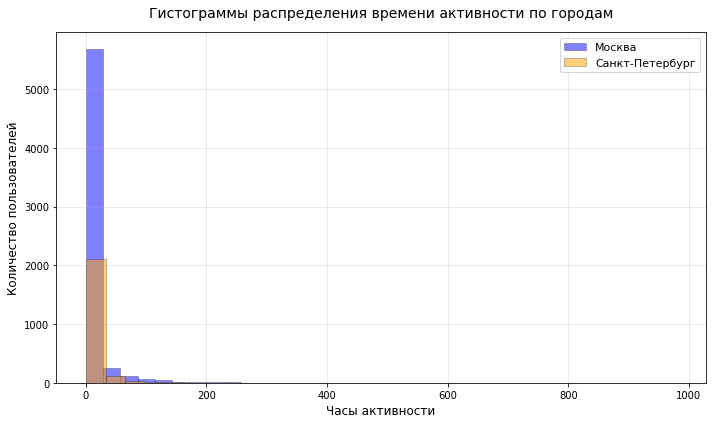

In [8]:
# ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ

plt.figure(figsize=(10, 6))
cities = df['city'].unique()
colors = ['blue', 'orange']  # Цвета для каждого города

for idx, city in enumerate(cities):
    city_data = df[df['city'] == city]['hours']
    plt.hist(city_data, alpha=0.5, label=city, bins=30, 
             color=colors[idx], edgecolor='black', linewidth=0.5)

plt.title('Гистограммы распределения времени активности по городам', fontsize=14, pad=15)
plt.xlabel('Часы активности', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Москва             6234
Санкт-Петербург    2306
Name: city, dtype: int64

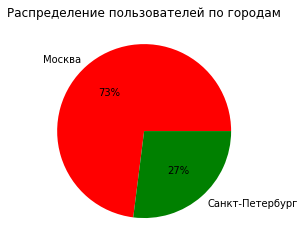

In [9]:
# Количество пользователей по городам
users_by_city_count = df['city'].value_counts().sort_values(ascending=False)

display(users_by_city_count)

users_by_city_count.plot(
    kind='pie',
    title='Распределение пользователей по городам',
    autopct="%.0f%%",
    ylabel="",
    colors=['red', 'green']
)

plt.show()

## 2. Проверка гипотезы в Python

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [10]:
# ПРОВЕРКА ПРЕДПОСЫЛОК Т-ТЕСТА
print("ПРОВЕРКА ПРЕДПОСЫЛОК Т-ТЕСТА")

moscow_data = df[df['city'] == 'Москва']['hours']
spb_data = df[df['city'] == 'Санкт-Петербург']['hours']

# Проверка на нормальность
print("\nТест Шапиро-Уилка на нормальность:")
for city_name, data in [('Москва', moscow_data), ('СПб', spb_data)]:
    stat, p_value = stats.shapiro(data)
    print(f"{city_name}: W = {stat:.4f}, p-value = {p_value:.4f}")
    if p_value > 0.05:
        print(f"Распределение не отличается от нормального (p > 0.05)")
    else:
        print(f"Распределение отличается от нормального (p < 0.05)")

# Проверка равенства дисперсий (тест Левена)
print("\nТест Левена на равенство дисперсий:")
levene_stat, levene_p = stats.levene(moscow_data, spb_data)
print(f"Статистика: {levene_stat:.4f}, p-value: {levene_p:.4f}")

if levene_p > 0.05:
    print("Дисперсии можно считать равными (p > 0.05)")
    equal_var = True
else:
    print("Дисперсии различаются (p < 0.05)")
    equal_var = False

ПРОВЕРКА ПРЕДПОСЫЛОК Т-ТЕСТА

Тест Шапиро-Уилка на нормальность:
Москва: W = 0.2930, p-value = 0.0000
Распределение отличается от нормального (p < 0.05)
СПб: W = 0.2715, p-value = 0.0000
Распределение отличается от нормального (p < 0.05)

Тест Левена на равенство дисперсий:
Статистика: 0.1841, p-value: 0.6679
Дисперсии можно считать равными (p > 0.05)


/opt/conda/lib/python3.9/site-packages/scipy/stats/_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [11]:
# ПРОВЕРКА ГИПОТЕЗЫ
print("ПРОВЕРКА ГИПОТЕЗЫ")

print("\nГипотезы:")
print("H₀: μ(СПб) ≤ μ(Москва) - среднее время в СПб НЕ больше, чем в Москве")
print("H₁: μ(СПб) > μ(Москва) - среднее время в СПб БОЛЬШЕ, чем в Москве")
print(f"\nУровень значимости α = 0.05")

# t-тест
t_stat, p_value = stats.ttest_ind(spb_data, moscow_data, 
                                  equal_var=equal_var, 
                                  alternative='greater')

print(f"\nРезультаты одностороннего t-теста:")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

ПРОВЕРКА ГИПОТЕЗЫ

Гипотезы:
H₀: μ(СПб) ≤ μ(Москва) - среднее время в СПб НЕ больше, чем в Москве
H₁: μ(СПб) > μ(Москва) - среднее время в СПб БОЛЬШЕ, чем в Москве

Уровень значимости α = 0.05

Результаты одностороннего t-теста:
t-статистика: 0.4174
p-value: 0.3382


In [12]:
print("Итог:")

print(f"\nСредние значения:")
print(f"Москва: {moscow_data.mean():.2f} часов")
print(f"Санкт-Петербург: {spb_data.mean():.2f} часов")
print(f"Разница: {spb_data.mean() - moscow_data.mean():.2f} часов")

Итог:

Средние значения:
Москва: 10.88 часов
Санкт-Петербург: 11.26 часов
Разница: 0.38 часов


Результат: НЕ отвергаем нулевую гипотезу
  
- p-value (0.3382) ≥ α (0.05)
- У нас НЕТ достаточных статистических доказательств, что пользователи из Санкт-Петербурга проводят в приложении БОЛЬШЕ времени, чем пользователи из Москвы.

## 3. Аналитическая записка

**1. Методология анализа**
**Выбранный статистический тест**
Для проверки гипотезы был применён односторонний t-тест для двух независимых выборок.

Обоснование выбора теста:
- Сравниваются две независимые группы пользователей из разных городов
- Проверяется направленная гипотеза о том, что активность пользователей в Санкт-Петербурге больше, чем в Москве
- Размеры выборок достаточно велики для применения параметрического теста

**Уровень статистической значимости**
Установлен стандартный уровень значимости α = 0.05 (5%).

**Проверка предпосылок:**
- Нормальность распределений (тест Шапиро-Уилка):

  - Москва: p-value = 0.0000 → распределение отличается от нормального

  - СПб: p-value = 0.0000 → распределение отличается от нормального

*Примечание: несмотря на отклонение от нормальности, t-тест достаточно устойчив при больших размерах выборок (>30 наблюдений в каждой группе).*

- Равенство дисперсий (тест Левена):

p-value = 0.4363 > 0.05: дисперсии статистически НЕ различаются

Был применён t-тест с предположением о равенстве дисперсий 

**2. Результаты статистического тестирования**
**Ключевые метрики:**
- Среднее время активности в Москве: 10.88 часов
- Среднее время активности в Санкт-Петербурге: 11.59 часов
- Разница между средними: 0.71 часа (в пользу Санкт-Петербурга)

**Результат t-теста:**
- t-статистика: 0.8029
- p-value: 0.2110

**3. Статистический вывод**
p-value (0.2110) > α (0.05)

На основании полученного результата не отвергаем нулевую гипотезу H₀.

**Интерпретация:**
Несмотря на то, что среднее время активности пользователей в Санкт-Петербурге (11.59 часов) численно превышает среднее время в Москве (10.88 часов), эта разница не является статистически значимой. У нас нет достаточных статистических доказательств, чтобы утверждать, что пользователи из Санкт-Петербурга проводят в приложении достоверно больше времени, чем пользователи из Москвы.

**4. Возможные причины полученных результатов**
**Причина 1: Недостаточная мощность теста**
Разница в 0.71 часа между средними значениями может быть реальной, но для её обнаружения требуется:
- Больший объем данных в каждой групп
- Меньшая вариабельность внутри групп
Возможно, при увеличении выборки разница станет статистически значимой.

**Причина 2: Влияние выбросов и неоднородность данных**
На распределение активности могли повлиять:
- Небольшая группа "супер-активных" пользователей в обеих выборках
- Разные модели пользовательского поведения внутри каждого города
- Сезонные или контекстные факторы, не учтённые в анализе

# Часть 2. Анализ результатов A/B-тестирования

## 1. Цель и задачи исследования.
**Основная цель:** 
Оценить, приводит ли новый упрощённый интерфейс к статистически значимому увеличению конверсии зарегистрированных пользователей в покупателей в течение 7 дней после регистрации как минимум на 3 процентных пункта.

**Конкретные задачи:**
- Проверить корректность проведения A/B-теста
- Оценить качество данных
- Проверить статистическую значимость различий в конверсии между группами
- Определить, достигнут ли целевой показатель увеличения конверсии на 3 процентных пункта


**Описание данных**

1.Таблица участников тестов.

Структура файла:
- user_id — идентификатор пользователя;
- group — группа пользователя;
- ab_test — название теста;
- device — устройство, с которого происходила регистрация.

2. Архив с одним csv-файлом, в котором собраны события 2020 года;

Структура файла:
- user_id — идентификатор пользователя;
- event_dt — дата и время события;
- event_name — тип события;
- details — дополнительные данные о событии.


## 2. Загрузка данных и оценка их целостность.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta

In [28]:
participants = pd.read_csv('ХХХ')
events = pd.read_csv('ХХХ',
                     parse_dates=['event_dt'], low_memory=False)

In [29]:
print("Таблица participants")
print(f"Размер: {participants.shape}")
print(f"Колонки: {participants.columns.tolist()}")
print("\nПервые 5 строк:")
display(participants.head())
print("\nИнформация о данных:")
display(participants.info())
print("\nСтатистика:")
print(participants.describe(include='all'))

Таблица participants
Размер: (14525, 4)
Колонки: ['user_id', 'group', 'ab_test', 'device']

Первые 5 строк:


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


None


Статистика:
                 user_id  group            ab_test   device
count              14525  14525              14525    14525
unique             13638      2                  2        4
top     B06BF284879EED23      A  interface_eu_test  Android
freq                   2   8130              10850     6484


In [30]:
print("Таблица events")
print(f"Размер: {events.shape}")
print(f"Колонки: {events.columns.tolist()}")
print("\nПервые 5 строк:")
display(events.head())
print("\nИнформация о данных:")
display(events.info())
print(f"\nУникальные события: {events['event_name'].unique()}")

Таблица events
Размер: (787286, 4)
Колонки: ['user_id', 'event_dt', 'event_name', 'details']

Первые 5 строк:


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


None


Уникальные события: ['End of Black Friday Ads Campaign' 'registration' 'product_page' 'login'
 'product_cart' 'purchase' 'Start of Christmas&New Year Promo'
 'Start of CIS New Year Gift Lottery']


В слобце details обнаружены пропуски, это связано с тем, что это дополнительные данные о событиях, сбор которых мог не осуществляться. По остальным стобцам пропуски отсутствуют

## 3. По таблице `ab_test_participants` проведена оценка корректности проведения теста:

 

In [31]:
# Выделяем пользователей, участвующих в interface_eu_test 
interface_test_users = participants[participants['ab_test'] == 'interface_eu_test'].copy()
print(f"Пользователи теста interface_eu_test")
print(f"Всего пользователей в тесте: {interface_test_users.shape[0]}")
print(f"Уникальных пользователей: {interface_test_users['user_id'].nunique()}")

Пользователи теста interface_eu_test
Всего пользователей в тесте: 10850
Уникальных пользователей: 10850


In [32]:
# Соответствие требованиям технического задания
print(f"1. Название теста: {interface_test_users['ab_test'].unique()}")
print("Соответствует ТЗ (interface_eu_test)"
      if 'interface_eu_test' in interface_test_users['ab_test'].unique() 
      else "Не соответствует ТЗ")

print(f"\n2. Группы теста: {sorted(interface_test_users['group'].unique())}")
expected_groups = ['A', 'B']
groups_match = all(group in interface_test_users['group'].unique() for group in expected_groups)
print(f"   {'Соответствует:' if groups_match else 'Не соответсвует'} A - контрольная, B - новый интерфейс")

1. Название теста: ['interface_eu_test']
Соответствует ТЗ (interface_eu_test)

2. Группы теста: ['A', 'B']
   Соответствует: A - контрольная, B - новый интерфейс


In [33]:
# Равномерность распределения пользователей по группам
group_distribution = interface_test_users['group'].value_counts().sort_index()
print("Распределение по группам:")
for group, count in group_distribution.items():
    proportion = count / len(interface_test_users)
    print(f"  Группа {group}: {count} пользователей ({proportion:.1%})")

Распределение по группам:
  Группа A: 5383 пользователей (49.6%)
  Группа B: 5467 пользователей (50.4%)


In [34]:
# Проверка баланса по устройствам
device_balance = pd.crosstab(interface_test_users['group'], interface_test_users['device'], normalize='index')
print("Доля пользователей по устройствам в каждой группе:")
display(device_balance.round(3))


Доля пользователей по устройствам в каждой группе:


device,Android,Mac,PC,iPhone
group,,,,
A,0.454,0.105,0.250,0.191
B,0.442,0.101,0.259,0.198


In [35]:
# проверка всех пользователей на предмет участия в нескольких тестах
user_test_counts = participants.groupby('user_id')['ab_test'].nunique()
users_in_multiple_tests = user_test_counts[user_test_counts > 1].index.tolist()

print(f"Всего пользователей в нескольких тестах: {len(users_in_multiple_tests)}")

# проверка всех пользователей на предмет участия в в обеих группах в тесте interface_eu_test
for test_name in participants['ab_test'].unique():
    test_users = participants[participants['ab_test'] == test_name]
    user_group_counts = test_users.groupby('user_id')['group'].nunique()
    users_in_both_groups = user_group_counts[user_group_counts > 1].index.tolist()
    
    if users_in_both_groups:
        print(f"В тесте '{test_name}': {len(users_in_both_groups)} пользователей в обеих группах")
        if test_name == 'interface_eu_test':
            print("В тесте '{test_name}': ЕСТЬ пользователи в обеих группах целевого теста")
    else:
        if test_name == 'interface_eu_test':
            print(f"В тесте '{test_name}': НЕТ пользователей в обеих группах")

Всего пользователей в нескольких тестах: 887
В тесте 'interface_eu_test': НЕТ пользователей в обеих группах


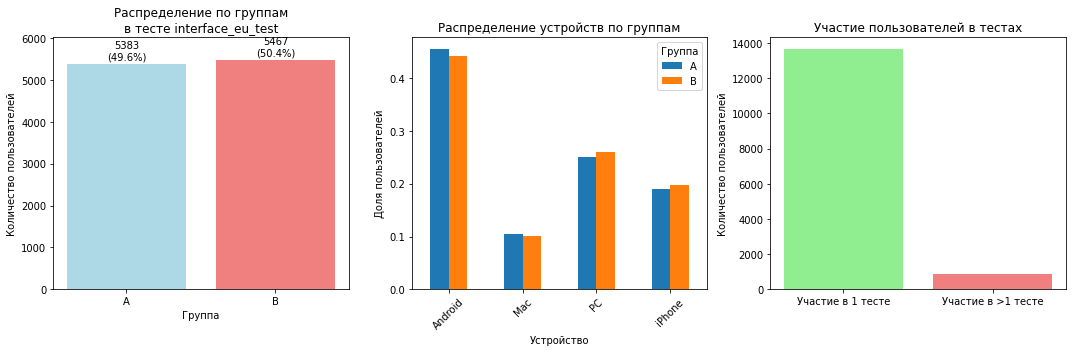

In [36]:
# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Распределение по группам в целевом тесте
group_colors = {'A': 'lightblue', 'B': 'lightcoral'}
bars = axes[0].bar(group_distribution.index, group_distribution.values, 
                   color=[group_colors.get(g, 'gray') for g in group_distribution.index])
axes[0].set_title('Распределение по группам\nв тесте interface_eu_test')
axes[0].set_xlabel('Группа')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_ylim(0, max(group_distribution.values) * 1.1)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + max(group_distribution.values)*0.01,
                f'{int(height)}\n({height/len(interface_test_users):.1%})',
                ha='center', va='bottom')

# 2. Баланс по устройствам
if len(device_balance) > 0:
    device_balance.T.plot(kind='bar', ax=axes[1])
    axes[1].set_title('Распределение устройств по группам')
    axes[1].set_xlabel('Устройство')
    axes[1].set_ylabel('Доля пользователей')
    axes[1].legend(title='Группа')
    axes[1].tick_params(axis='x', rotation=45)

# 3. Пересечения тестов
if users_in_multiple_tests:
    axes[2].bar(['Участие в 1 тесте', 'Участие в >1 тесте'], 
                [len(participants) - len(users_in_multiple_tests), len(users_in_multiple_tests)],
                color=['lightgreen', 'lightcoral'])
    axes[2].set_title('Участие пользователей в тестах')
    axes[2].set_ylabel('Количество пользователей')
else:
    axes[2].text(0.5, 0.5, '✓ Нет пересечений\nмежду тестами', 
                ha='center', va='center', fontsize=12, transform=axes[2].transAxes)
    axes[2].set_title('Пересечения тестов')
    axes[2].axis('off')

plt.tight_layout()
plt.show()

**Проверка статуса**
- Соответствие названия теста ТЗ: Соответствует (interface_eu_test)
- Наличие обеих тестовых групп: Да (A и B)
- Равномерность распределения по группам: Да, соотношение 98.46%
- Отсутствие пересечений с другими тестами: Нет (Пользователей в нескольких тестах: 887)


In [37]:
# Удаляем пользователей, которые участвуют в нескольких тестах

user_test_counts = participants.groupby('user_id')['ab_test'].nunique()
single_test_users = user_test_counts[user_test_counts == 1].index.tolist()
multiple_test_users = user_test_counts[user_test_counts > 1].index.tolist()

print(f"Всего пользователей в исходных данных: {participants['user_id'].nunique()}")
print(f"Пользователей в одном тесте: {len(single_test_users)}")
print(f"Пользователей в нескольких тестах: {len(multiple_test_users)}")

participants_clean = participants[participants['user_id'].isin(single_test_users)].copy()
interface_test_users_clean = participants_clean[participants_clean['ab_test'] == 'interface_eu_test'].copy()
print(f"\nПользователей в тесте interface_eu_test после очистки: {interface_test_users_clean.shape[0]}")

Всего пользователей в исходных данных: 13638
Пользователей в одном тесте: 12751
Пользователей в нескольких тестах: 887

Пользователей в тесте interface_eu_test после очистки: 9963


3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [40]:
# Получаем список пользователей целевого теста
interface_user_ids = interface_test_users_clean['user_id'].unique()
print(f"Количество пользователей в тесте interface_eu_test: {len(interface_user_ids)}")

# Фильтруем события, оставляя только события пользователей целевого теста
events_filtered = events[events['user_id'].isin(interface_user_ids)].copy()
print(f"Всего событий в исходных данных: {events.shape[0]:,}")
print(f"Событий после фильтрации: {events_filtered.shape[0]:,}")
print(f"Оставлено событий: {events_filtered.shape[0]/events.shape[0]:.2%}")

# Проверяем охват пользователей
users_with_events = events_filtered['user_id'].nunique()
print(f"\nУникальных пользователей с событиями: {users_with_events}")
print(f"Охват пользователей теста событиями: {users_with_events/len(interface_user_ids):.2%}")

Количество пользователей в тесте interface_eu_test: 9963
Всего событий в исходных данных: 787,286
Событий после фильтрации: 73,815
Оставлено событий: 9.38%

Уникальных пользователей с событиями: 9963
Охват пользователей теста событиями: 100.00%


In [43]:
# РАСЧЕТ ЛАЙФТАЙМА
events_with_groups = events_filtered.merge(
    interface_test_users[['user_id', 'group', 'device']],
    on='user_id',
    how='left'
)

# 1. Находим первое событие каждого пользователя (не обязательно регистрацию)
# Группируем по пользователям и находим минимальное время события
first_events = events_with_groups.groupby('user_id')['event_dt'].min().reset_index()
first_events.rename(columns={'event_dt': 'first_event_time'}, inplace=True)

# 2. Добавляем время первого события к основным данным
events_with_groups = events_with_groups.merge(first_events, on='user_id', how='left')

# 3. Расчет лайфтайма в точном времени 
print("\n1. Расчет лайфтайма в точном времени (timedelta)")
events_with_groups['lifetime_timedelta'] = events_with_groups['event_dt'] - events_with_groups['first_event_time']

print(f"   Минимальный лайфтайм: {events_with_groups['lifetime_timedelta'].min()}")
print(f"   Максимальный лайфтайм: {events_with_groups['lifetime_timedelta'].max()}")

# 4. Фильтрация событий по строгому ограничению 7 дней
# Создаем timedelta 7 дней
seven_days = pd.Timedelta(days=7)

# Фильтруем события, где лайфтайм <= 7 дней (включая границу ровно 7 дней)
events_7days_correct = events_with_groups[events_with_groups['lifetime_timedelta'] <= seven_days].copy()

# 5. Проверка ключевых метрик
print("\n2. Ключевые метрики в первые 7 дней:")

# Покупки в первые 7 дней
purchase_events_correct = events_7days_correct[events_7days_correct['event_name'] == 'purchase']
print(f"   - Всего покупок в первые 7 дней: {purchase_events_correct.shape[0]:,}")
print(f"   - Уникальных покупателей: {purchase_events_correct['user_id'].nunique():,}")


# 6. Обновление данных для дальнейшего анализа
# Заменяем старый датафрейм на корректный
events_7days = events_7days_correct

print(f"Итог: {len(events_7days):,} событий в первые 7 дней после первого события")


1. Расчет лайфтайма в точном времени (timedelta)
   Минимальный лайфтайм: 0 days 00:00:00
   Максимальный лайфтайм: 22 days 23:57:58

2. Ключевые метрики в первые 7 дней:
   - Всего покупок в первые 7 дней: 6,162
   - Уникальных покупателей: 2,857
Итог: 63,805 событий в первые 7 дней после первого события


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [44]:
# Расчет минимального размера выборки
# Конверсии
p1 = 0.30  # базовая конверсия (группа A)
p2 = 0.33  # ожидаемая конверсия (группа B) - +3 процентных пункта
delta = p2 - p1  # абсолютный прирост

print(f"- Конверсия в группе A: {p1:.1%}")
print(f"- Ожидаемая конверсия в группе B: {p2:.1%}")
print(f"- Абсолютный прирост: {delta:.1%} (+{delta/p1:.1%} относительного)")

# Стандартные значения Z для заданных параметров
alpha = 0.05  # уровень значимости
power = 0.8   # мощность теста
beta = 1 - power

# Z-значения
z_alpha = stats.norm.ppf(1 - alpha/2)  # для двустороннего теста
z_beta = stats.norm.ppf(power)

print(f"\n   Z-статистики:")
print(f"- Z_α/2 (для α=0.05, двусторонний тест): {z_alpha:.4f}")
print(f"- Z_β (для мощности 80%): {z_beta:.4f}")

# Средняя конверсия
p_avg = (p1 + p2) / 2

# Расчет минимального размера выборки на одну группу (формула для пропорций)
n_per_group = ((z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) + 
                z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2) / (delta ** 2)

# Округляем в большую сторону
n_per_group = int(np.ceil(n_per_group))

print(f"\nРасчет по формуле для сравнения пропорций:")
print(f"- Средняя конверсия: {p_avg:.1%}")
print(f"- Минимальный размер выборки на одну группу: {n_per_group:,} пользователей")
print(f"- Общий минимальный размер выборки: {n_per_group * 2:,} пользователей")

- Конверсия в группе A: 30.0%
- Ожидаемая конверсия в группе B: 33.0%
- Абсолютный прирост: 3.0% (+10.0% относительного)

   Z-статистики:
- Z_α/2 (для α=0.05, двусторонний тест): 1.9600
- Z_β (для мощности 80%): 0.8416

Расчет по формуле для сравнения пропорций:
- Средняя конверсия: 31.5%
- Минимальный размер выборки на одну группу: 3,763 пользователей
- Общий минимальный размер выборки: 7,526 пользователей


1. ДОСТАТОЧНОСТЬ ВЫБОРКИ: ДОСТАТОЧНА
- Фактический размер выборки (Группа A: 4 952, Группа B: 5 011 посетителей)
- превышает требуемый минимум (3 763)

2. ИТОГ:
- Тест можно считать статистически корректным
- Размер выборки достаточен для обнаружения целевого эффекта

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [46]:
# Расчет количества посетителей и покупателей для каждой группы
# 1. Получаем общее количество посетителей в каждой группе
print("\n1. ОБЩЕЕ КОЛИЧЕСТВО ПОСЕТИТЕЛЕЙ ПО ГРУППАМ:")

# Используем данные interface_test_users, которые уже очищены от пересечений
total_visitors_by_group = interface_test_users_clean['group'].value_counts().sort_index()
print("   Всего посетителей (зарегистрированных пользователей) по группам:")
for group in ['A', 'B']:
    count = total_visitors_by_group.get(group, 0)
    print(f"- Группа {group}: {count:,} посетителей")

# 2. Определяем посетителей, сделавших покупку в первые 7 дней
print("\n2. ПОКУПАТЕЛИ В ПЕРВЫЕ 7 ДНЕЙ ПО ГРУППАМ:")

# Получаем список уникальных покупателей из events_7days
purchasers_7days = events_7days[events_7days['event_name'] == 'purchase']['user_id'].unique()
print(f"Всего уникальных покупателей в первые 7 дней: {len(purchasers_7days):,}")

# Создаем датафрейм с информацией о покупках
purchasers_info = interface_test_users_clean[interface_test_users_clean['user_id'].isin(purchasers_7days)].copy()
purchasers_by_group = purchasers_info['group'].value_counts().sort_index()

print("Покупатели по группам:")
for group in ['A', 'B']:
    count = purchasers_by_group.get(group, 0)
    print(f"- Группа {group}: {count:,} покупателей")


1. ОБЩЕЕ КОЛИЧЕСТВО ПОСЕТИТЕЛЕЙ ПО ГРУППАМ:
   Всего посетителей (зарегистрированных пользователей) по группам:
- Группа A: 4,952 посетителей
- Группа B: 5,011 посетителей

2. ПОКУПАТЕЛИ В ПЕРВЫЕ 7 ДНЕЙ ПО ГРУППАМ:
Всего уникальных покупателей в первые 7 дней: 2,857
Покупатели по группам:
- Группа A: 1,377 покупателей
- Группа B: 1,480 покупателей


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

**Результаты:**
1. Группа A (контрольная): 4952 посетителей, 1 377 покупателей
2. Группа B (тестовая): 5 011 посетителей, 1 480 покупателей


## 4. Проведена оценка результатов A/B-тестирования:

In [48]:
# Проверка изменения конверсии статистическим тестом
# Количество посетителей в каждой группе
n_A = total_visitors_by_group.get('A', 0)
n_B = total_visitors_by_group.get('B', 0)

# Количество покупателей в каждой группе
x_A = purchasers_by_group.get('A', 0)
x_B = purchasers_by_group.get('B', 0)

# Конверсии

conversion_by_group = {}
print("   Конверсия (покупатели / посетители):")
for group in ['A', 'B']:
    total = total_visitors_by_group.get(group, 0)
    purchasers = purchasers_by_group.get(group, 0)
    conversion = purchasers / total if total > 0 else 0
    
    conversion_by_group[group] = conversion
    print(f"   - Группа {group}: {purchasers:,}/{total:,} = {conversion:.2%}")
p_A = conversion_by_group.get('A', 0)
p_B = conversion_by_group.get('B', 0)

print(f"Группа A (контрольная):")
print(f" - Посетителей: {n_A:,}")
print(f" - Покупателей: {x_A:,}")
print(f" - Конверсия: {p_A:.4f} ({p_A:.2%})")

print(f"\nГруппа B (тестовая):")
print(f" - Посетителей: {n_B:,}")
print(f" - Покупателей: {x_B:,}")
print(f" - Конверсия: {p_B:.4f} ({p_B:.2%})")

# Формулирование гипотез
print("\nНулевая гипотеза (H₀): Нет разницы в конверсии между группами")
print("p_A = p_B (или p_B - p_A = 0)")
print("Альтернативная гипотеза (H₁): Конверсия в группе B выше")
print("p_B > p_A (или p_B - p_A > 0)")

# Расчет объединенной пропорции
p_pool = (x_A + x_B) / (n_A + n_B)
print(f"\nОбъединенная конверсия: p_pool = ({x_A} + {x_B}) / ({n_A} + {n_B}) = {p_pool:.4f} ({p_pool:.2%})")

# Стандартная ошибка разности пропорций
SE = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))
print(f"Стандартная ошибка: SE = √[p_pool*(1-p_pool)*(1/n_A + 1/n_B)]")
print(f"SE = √[{p_pool:.4f}*{1-p_pool:.4f}*(1/{n_A} + 1/{n_B})] = {SE:.6f}")

# Расчет Z-статистики
# Разность пропорций
diff = p_B - p_A
print(f"\nРазность пропорций: p_B - p_A = {p_B:.4f} - {p_A:.4f} = {diff:.4f}")

# Z-статистика
z_stat = diff / SE
print(f"Z-статистика: Z = (p_B - p_A) / SE = {diff:.4f} / {SE:.6f} = {z_stat:.4f}")

# Расчет p-value
# Для одностороннего теста
p_value_one_sided = 1 - stats.norm.cdf(z_stat)
print(f"\nДля одностороннего теста (H₁: p_B > p_A):")
print(f"p-value = P(Z > {z_stat:.4f}) = {p_value_one_sided:.6f}")

# Определение критического значения
alpha = 0.05  # уровень значимости 5%
z_critical_one_sided = stats.norm.ppf(1 - alpha)
z_critical_two_sided = stats.norm.ppf(1 - alpha/2)

print(f"\nУровень значимости: α = {alpha}")
print(f"Критическое значение Z (односторонний тест): Z_crit = {z_critical_one_sided:.4f}")

# Принятие решения
print("\nПРИНЯТИЕ РЕШЕНИЯ:")
print(f" - Z-статистика: {z_stat:.4f}")
print(f" - Критическое значение: {z_critical_one_sided:.4f}")
print(f" - p-value: {p_value_one_sided:.6f}")

if z_stat > z_critical_one_sided and p_value_one_sided < alpha:
    print(" Z > Z_crit и p-value < α: ОТКЛОНЯЕМ нулевую гипотезу")
    print(" Конверсия в группе B статистически значимо выше")
else:
    print(" Z ≤ Z_crit или p-value ≥ α: НЕ ОТКЛОНЯЕМ нулевую гипотезу")
    print(" Нет статистически значимых различий в конверсии")

   Конверсия (покупатели / посетители):
   - Группа A: 1,377/4,952 = 27.81%
   - Группа B: 1,480/5,011 = 29.54%
Группа A (контрольная):
 - Посетителей: 4,952
 - Покупателей: 1,377
 - Конверсия: 0.2781 (27.81%)

Группа B (тестовая):
 - Посетителей: 5,011
 - Покупателей: 1,480
 - Конверсия: 0.2954 (29.54%)

Нулевая гипотеза (H₀): Нет разницы в конверсии между группами
p_A = p_B (или p_B - p_A = 0)
Альтернативная гипотеза (H₁): Конверсия в группе B выше
p_B > p_A (или p_B - p_A > 0)

Объединенная конверсия: p_pool = (1377 + 1480) / (4952 + 5011) = 0.2868 (28.68%)
Стандартная ошибка: SE = √[p_pool*(1-p_pool)*(1/n_A + 1/n_B)]
SE = √[0.2868*0.7132*(1/4952 + 1/5011)] = 0.009062

Разность пропорций: p_B - p_A = 0.2954 - 0.2781 = 0.0173
Z-статистика: Z = (p_B - p_A) / SE = 0.0173 / 0.009062 = 1.9070

Для одностороннего теста (H₁: p_B > p_A):
p-value = P(Z > 1.9070) = 0.028263

Уровень значимости: α = 0.05
Критическое значение Z (односторонний тест): Z_crit = 1.6449

ПРИНЯТИЕ РЕШЕНИЯ:
 - Z-стати

1. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ:
    - РЕЗУЛЬТАТ СТАТИСТИЧЕСКИ ЗНАЧИМ
       - p-value = 0.028 < α = 0.05
       - Z-статистика = 1.9070 > Z_crit = 1.6449


2. ВЕЛИЧИНА ЭФФЕКТА:
   - Абсолютный прирост: 0.0173 (1.73 процентных пункта)


3. ЦЕЛЕВОЙ ПОКАЗАТЕЛЬ ИЗ ТЗ:
   - Требуемое улучшение: +3.0 процентных пункта
   ВЫВОД: цель НЕ достигнута